# Projet Scoring

### Importation des libraries :

In [8]:
import pandas as pd # test
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, chi2_contingency
from optbinning import OptimalBinning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import statsmodels.api as sm

# ETAPE 1 : EDA

In [9]:
1+2

3

In [10]:
df = pd.read_csv("../data/credit_risk_dataset.csv", sep=',')

In [11]:
df = df[df["person_age"]<=100]
df = df[(df["person_emp_length"]<=41)|(df["person_emp_length"].isna())]

- On écarte les individus âgés de plus de 100 ans
- On écarte les individus qui ont une durée d'emploi <= 41 ans
- les person_emp_length > 41 ans sont au nombre de 2 et ont 123 ans de durée de travail (ce qui est anormal)

In [12]:
column_num = df.select_dtypes(include=['float64', 'int64']).columns.drop('loan_status')
column_cat = df.select_dtypes(include=['object']).columns.drop('loan_grade')

- On séléctionne toutes les variables numérique et drop loan_status
- on séléctionne toutes les variables catégorielles et drop loan_grade

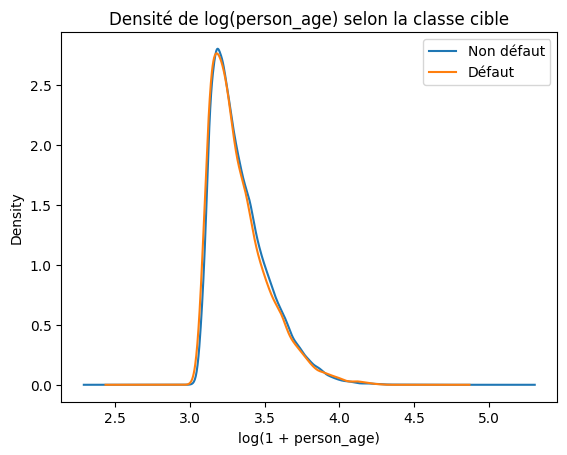

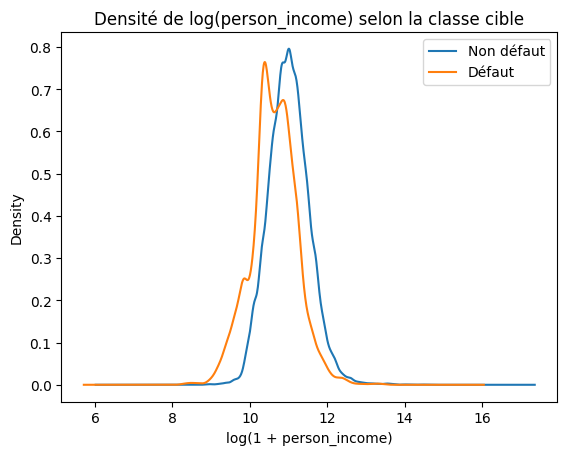

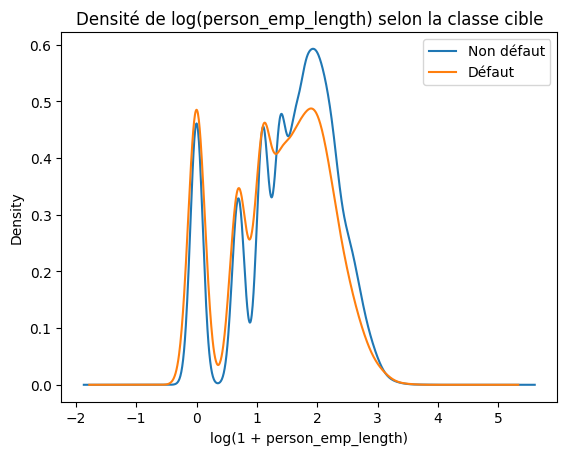

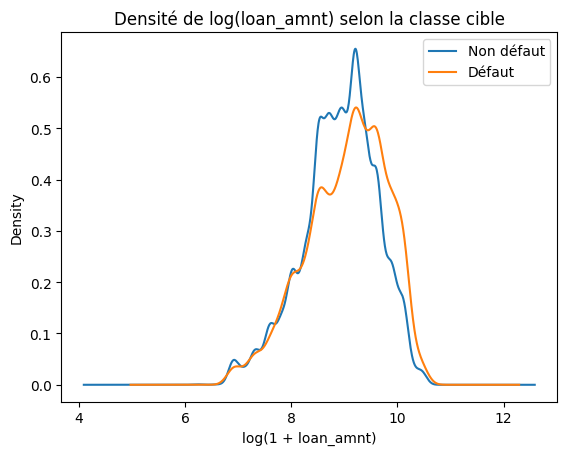

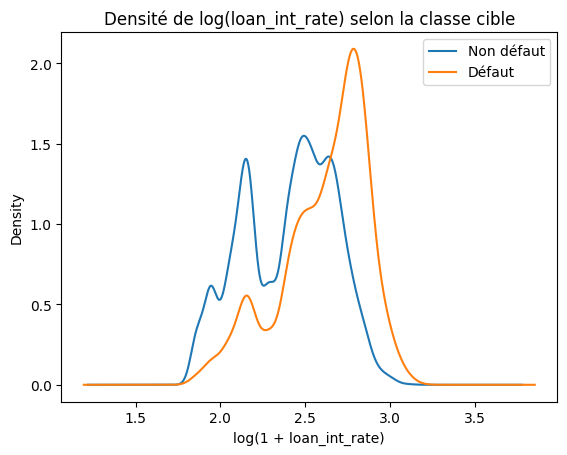

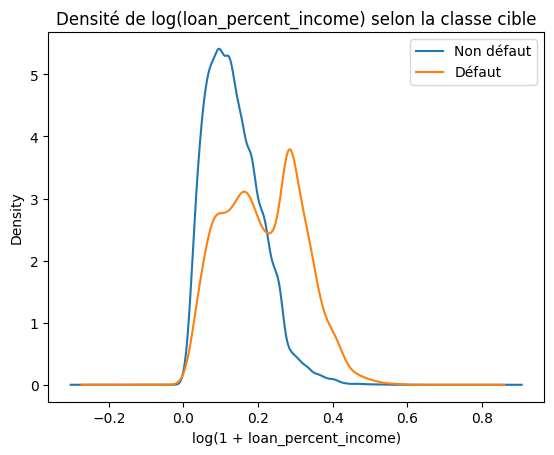

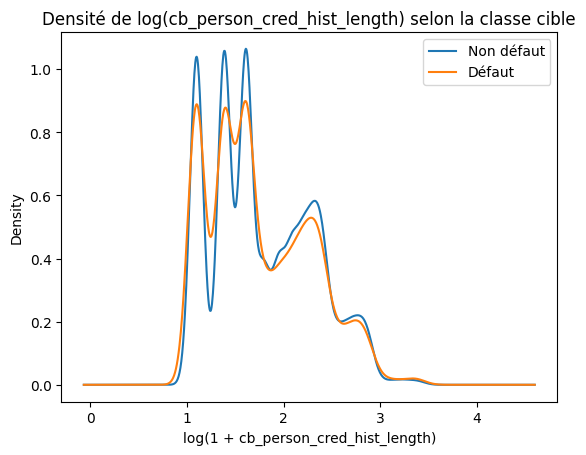

In [13]:
import numpy as np
for col in column_num:
    plt.figure()

    x0 = df.loc[df['loan_status'] == 0, col]
    x1 = df.loc[df['loan_status'] == 1, col]

    np.log1p(x0).dropna().plot(kind='density', label='Non défaut')
    np.log1p(x1).dropna().plot(kind='density', label='Défaut')

    plt.title(f'Densité de log({col}) selon la classe cible')
    plt.xlabel(f'log(1 + {col})')
    plt.legend()
    plt.show()


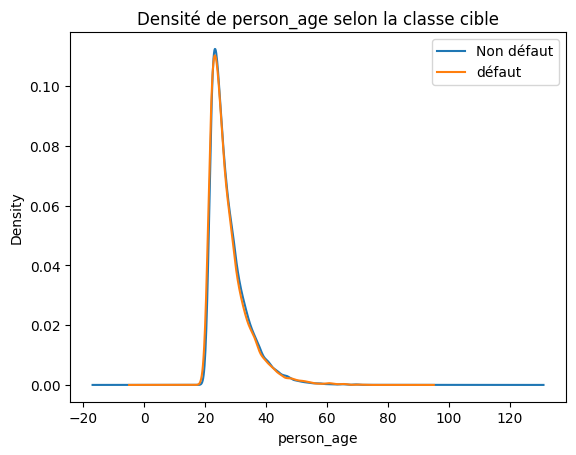

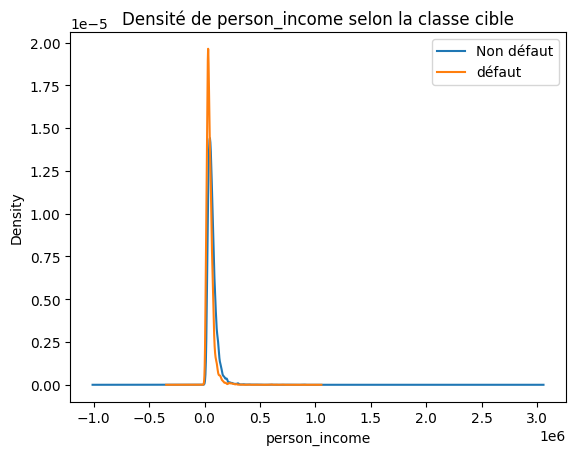

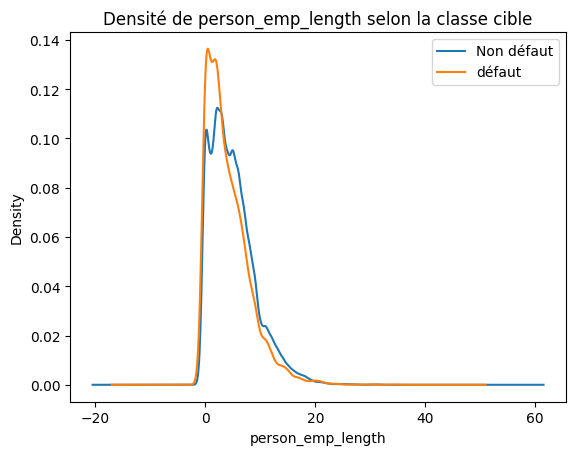

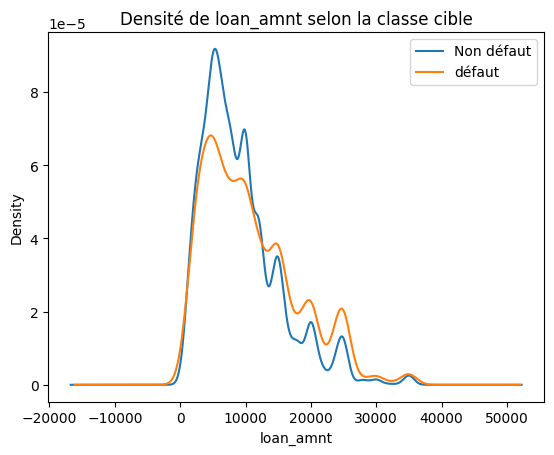

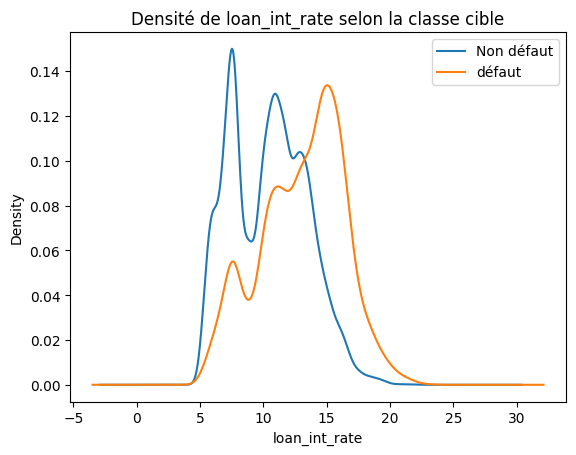

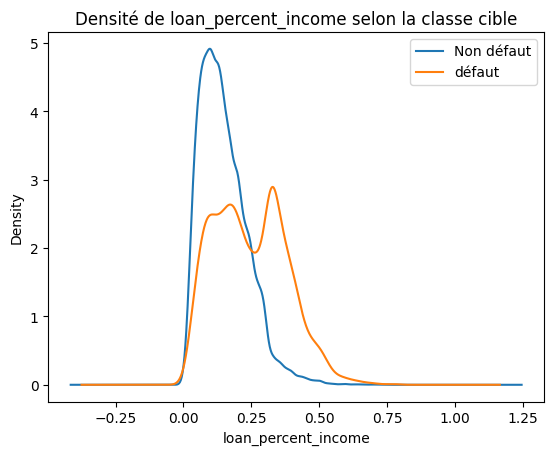

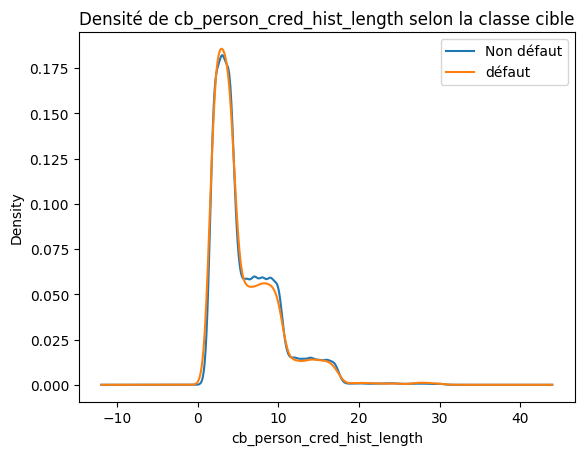

In [14]:
for col in column_num:
    plt.figure()
    df[df['loan_status']==0][col].plot(kind='density', label='Non défaut')
    df[df['loan_status']==1][col].plot(kind='density', label='défaut')
    plt.title(f'Densité de {col} selon la classe cible')
    plt.xlabel(col)
    plt.legend()
    plt.show()

**Test de Kolmogorov :**

- Pour chaque variable explicative, on teste si sa distribution est la même chez :
    - les non-défaillants (loan_status = 0)
    - les défaillants (loan_status = 1)

Si les distributions sont identiques ou très proches :
- la variable ne discrimine pas → elle sert peu en scoring.

In [15]:
ks_results = []

for col in column_num:
    # Séparer les groupes
    data0 = df[df['loan_status'] == 0][col].dropna()
    data1 = df[df['loan_status'] == 1][col].dropna()
    
    # Test KS
    stat, p_value = ks_2samp(data0, data1)
    
    ks_results.append({
        'variable': col,
        'KS_stat': stat,
        'p_value': p_value
    })

ks_df = pd.DataFrame(ks_results).sort_values(by='KS_stat', ascending=False)
print(ks_df)

## Les distributions ne sont pas indentiques (p_value < 0,05)

                     variable   KS_stat       p_value
5         loan_percent_income  0.351535  0.000000e+00
4               loan_int_rate  0.335609  0.000000e+00
1               person_income  0.280457  0.000000e+00
3                   loan_amnt  0.116821  1.617359e-66
2           person_emp_length  0.111786  9.660752e-59
0                  person_age  0.034802  2.784286e-06
6  cb_person_cred_hist_length  0.029066  1.640317e-04


### Decoupage en train et test

- On crée un Train et un Test set : En stratifiant selon les variables catégorielles et la variables cible
- On force pour que chaque type de client apparaisse dans le train ET dans le test dans les mêmes proportions

In [16]:
# On crée la variable de stratification en concatenant les colonnes des variables catégorielle
# On s'assure aussi que ce soit stratifié selon la variable cible
df['label_loan_status'] = df['loan_status'].astype('category')
df["stratify_col"] = df["label_loan_status"].astype(str) + "_" + df["person_home_ownership"].astype(str) + "_" + df["loan_intent"].astype(str) + "_" + df["cb_person_default_on_file"].astype(str)
df = df.drop(columns=["label_loan_status"])

On regroupe les profils clients rares afin de permettre une stratification correcte lors du découpage train/test.

- stratify_col = types de clients
- certains types apparaissent 1 seule fois
- impossible de stratifier avec ça
- on les met tous dans "Other"

In [17]:
# On regroupe les labels rares (qui on qu'une seule modalité) ensemble, pour pouvoir spliter
counts = df["stratify_col"].value_counts()
rare_labels = counts[counts < 2].index
df["stratify_col"] = df["stratify_col"].replace(rare_labels, "Other")

Le découpage train/test permet d’évaluer la capacité du modèle de scoring à prédire le défaut sur des emprunteurs jamais observés.

In [18]:
df_train_set, df_test_set = train_test_split(df, test_size=0.2, stratify=df["stratify_col"], random_state=42)
df_train_set = df_train_set.drop(columns=["stratify_col"])
df_test_set = df_test_set.drop(columns=["stratify_col"])

In [19]:
# print((df_train_set["loan_status"].value_counts())/len(df_train_set))
# print((df_test_set["loan_status"].value_counts())/len(df_test_set))
# (df["loan_status"].value_counts())/len(df)

## Exploration de la base de donnée

In [20]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)

column_num = df_train_set.select_dtypes(include=['float64', 'int64']).columns.drop('loan_status')
column_cat = df_train_set.select_dtypes(include=['object']).columns.drop('loan_grade')
df_train_set.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,26059.000,26059.000,25346.000,26059.000,23575.000,26059.000,26059.000,26059.000
mean,27.719,65910.085,4.779,9620.020,11.015,0.218,0.171,5.809
std,6.194,51820.041,4.018,6360.800,3.236,0.413,0.107,4.047
min,20.000,4000.000,0.000,500.000,5.420,0.000,0.000,2.000
25%,23.000,38400.000,2.000,5000.000,7.900,0.000,0.090,3.000
50%,26.000,55000.000,4.000,8000.000,10.990,0.000,0.150,4.000
75%,30.000,79050.000,7.000,12250.000,13.470,0.000,0.230,8.000
max,94.000,1900000.000,41.000,35000.000,23.220,1.000,0.830,30.000


In [21]:
df_train_set["person_income"].sort_values(ascending=False).head(20)

32546    1900000
32497    1782000
31922    1362000
17833    1200000
29120    1200000
17834     948000
31921     900000
29122     900000
29121     900000
32298     900000
31919     828000
32037     828000
31918     800000
32551     780000
31916     780000
32544     780000
28253     762000
27884     762000
27883     750000
27882     741600
Name: person_income, dtype: int64

In [22]:
# df_train_set_del_missing_variable = df_train_set[(~df_train_set['loan_int_rate'].isna())&(~df_train_set['person_emp_length'].isna())].copy()
# df_train_set_del_loan_int_rate = df_train_set[~df_train_set['loan_int_rate'].isna()].copy()
# df_train_set_del_person_emp_length = df_train_set[~df_train_set['person_emp_length'].isna()].copy()

# Etape 2 : Discrétisation et Regroupement

In [23]:
dff = df_train_set.copy()

In [24]:
dff.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

- Visualisation de la discrétisation avec Optimal Binning

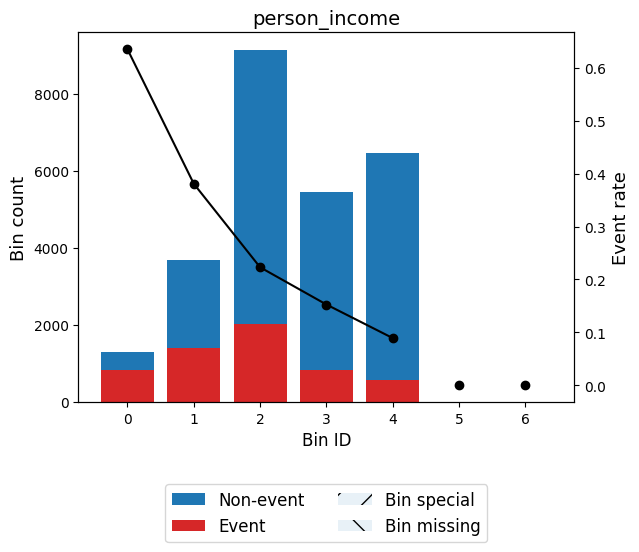

In [25]:
## GROUPEMENT VAR QUANT : L'IV mesure la capacité d’une variable à discriminer les bons et les mauvais payeurs (< 0.02 : inutile).
variable = 'person_income'
optb = OptimalBinning(name=variable, dtype="numerical", solver="cp", min_n_bins=5, max_n_bins=5)  # "cp" = solver par défaut (constraint programming)
optb.fit(dff[variable], dff['loan_status'])

bin_table = optb.binning_table.build()
# print(bin_table)
optb.binning_table.plot(metric="event_rate")

In [26]:
# loan_intent, person_home_ownership
variable = 'loan_intent'
optb = OptimalBinning(name=variable, dtype='categorical', max_n_bins=4)
optb.fit(dff[variable], dff['loan_status'])
print(optb.binning_table.build())   # voir les groupes, WoE, IV

                                                  Bin  Count  Count (%)  \
0                                           [VENTURE]   4572      0.175   
1                                         [EDUCATION]   5160      0.198   
2                                          [PERSONAL]   4417      0.169   
3       [HOMEIMPROVEMENT, MEDICAL, DEBTCONSOLIDATION]  11910      0.457   
4                                             Special      0      0.000   
5                                             Missing      0      0.000   
Totals                                                 26059      1.000   

        Non-event  Event  Event rate    WoE    IV    JS  
0            3895    677       0.148  0.474 0.034 0.004  
1            4271    889       0.172  0.293 0.016 0.002  
2            3539    878       0.199  0.118 0.002 0.000  
3            8668   3242       0.272 -0.293 0.042 0.005  
4               0      0       0.000  0.000 0.000 0.000  
5               0      0       0.000  0.000 0.000 0

In [27]:
# ## GROUPEMENT VAR QUAL
# var = "classe_loan_intent"
# print((dff[var].value_counts())/len(dff))
# dff.groupby(dff[var])["loan_status"].mean()

In [28]:
########################### FONCTIONS POUR DISCRETISER  ##########################################################
## Variable Age
def cat_age(data:pd.DataFrame, nb_classe:int) -> pd.DataFrame:    ## Tester avec 3 et 2 classes
    if nb_classe==3:
        conditions_age = [data["person_age"] < 22.50,  
                  data["person_age"] >= 28.50,
                  ((data["person_age"] >= 22.50) & (data["person_age"] < 28.50))             
              ]
        choix_age = ["Jeunes instables", "seniors", "Jeunes"]
        data["classe_age"] = np.select(conditions_age, choix_age, default=None)  
    elif nb_classe==2:
         conditions_age = [data["person_age"] < 22.50,  
                  data["person_age"] >= 22.50          
              ]
         choix_age = ["Juniors", "seniors"]
         data["classe_age_2"] = np.select(conditions_age, choix_age, default=None)
    return data

def cat_income(data):
    conditions_income = [data["person_income"] < 22806.00,
                     data["person_income"] >= 79993.50,
                     (data["person_income"] >= 59853.50) & (data["person_income"] < 79993.50),
                     (data["person_income"] >= 34990.00) & (data["person_income"] < 59853.50),
                     (data["person_income"] >= 22806.00) & (data["person_income"] < 34990.00)                               
              ]
    choix_income = ["(-inf, 22806.00)", "[79993.50, inf)", "[59853.50, 79993.50)", "[34990.00, 59853.50)", "[22806.00, 34990.00)"]
    data["classe_income"] = np.select(conditions_income, choix_income, default=None) # Relation monotone décroissante
    return data

def cat_emp_length(data, nb_classe):
    if nb_classe == 5:
        conditions_emp = [data["person_emp_length"].isna(),
                  data["person_emp_length"] < 1.50,
                  data["person_emp_length"] >= 7.50,
                  (data["person_emp_length"] >= 2.50) & (data["person_emp_length"] < 7.50),
                  (data["person_emp_length"] >= 1.50) & (data["person_emp_length"] < 2.50)
              ]

        choix_emp = ["Missing","(-inf, 1.50)", "[7.50, inf)", "[2.50, 7.50)", "[1.50, 2.50)"]
        data["classe_emp"] = np.select(conditions_emp, choix_emp, default=None)  # Relation monotone décroissante
    elif nb_classe == 4:
        conditions_emp = [(data["person_emp_length"].isna())|(data["person_emp_length"] < 1.50),  # 2 ème cas : je regroupe les sans_emploi et courte durée d'emploi              
                 data["person_emp_length"] >= 7.50,
                  (data["person_emp_length"] >= 2.50) & (data["person_emp_length"] < 7.50),
                  (data["person_emp_length"] >= 1.50) & (data["person_emp_length"] < 2.50)
              ]
        choix_emp = ["no_emp et < 1.50", "[7.50, inf)", "[2.50, 7.50)", "[1.50, 2.50)"]
        data["classe_emp_2"] = np.select(conditions_emp, choix_emp, default=None)
    return data

def cat_emp_length_imputed(data, nb_classe):
    if nb_classe == 4:
        conditions_emp = [data["emp_imputed"] < 2.50,
                  data["emp_imputed"] >= 7.50,
                  (data["emp_imputed"] >= 4.50) & (data["emp_imputed"] < 7.50),
                  (data["emp_imputed"] >= 2.50) & (data["emp_imputed"] < 4.50)
              ]

        choix_emp = ["(-inf, 2.50)", "[7.50, inf)", "[4.50, 7.50)", "[2.50, 4.50)"]
        data["classe_emp_imp_4"] = np.select(conditions_emp, choix_emp, default=None)  # Relation monotone décroissante
    elif nb_classe == 3:
        conditions_emp = [data["emp_imputed"] < 2.50,        
                 data["emp_imputed"] >= 7.50,
                  (data["emp_imputed"] >= 2.50) & (data["emp_imputed"] < 7.50)
              ]
        choix_emp = ["(-inf, 2.50)", "[7.50, inf)", "[2.50, 7.50)"]
        data["classe_emp_imp_3"] = np.select(conditions_emp, choix_emp, default=None)
    return data

def cat_amnt(data):
    conditions_amnt = [data["loan_amnt"] < 5012.50,
                     data["loan_amnt"] >= 18087.50,
                     (data["loan_amnt"] >= 14062.50) & (data["loan_amnt"] < 18087.50),
                     (data["loan_amnt"] >= 7487.50) & (data["loan_amnt"] < 14062.50),
                     (data["loan_amnt"] >= 5012.50) & (data["loan_amnt"] < 7487.50)                               
              ]

    choix_amnt = ["(-inf, 5012.50)", "[18087.50, inf)", "[14062.50, 18087.50)", "[7487.50, 14062.50)", "[5012.50, 7487.50)"]
    data["classe_amnt"] = np.select(conditions_amnt, choix_amnt, default=None)  # Relation en U (tester un autre regroupement si ce n'est pas significatif)
    return data

def cat_int_rate(data):
    conditions_int_rate = [data["loan_int_rate"].isna(),
                     data["loan_int_rate"] < 7.89,
                     data["loan_int_rate"] >= 15.28,
                     (data["loan_int_rate"] >= 14.37) & (data["loan_int_rate"] < 15.28),
                     (data["loan_int_rate"] >= 12.07) & (data["loan_int_rate"] < 14.37),
                     (data["loan_int_rate"] >= 7.89) & (data["loan_int_rate"] < 12.07)                               
              ]

    choix_int_rate = ["Missing","(-inf, 7.89)", "[15.28, inf)", "[14.37, 15.28)", "[12.07, 14.37)", "[7.89, 12.07)"]
    data["classe_int_rate"] = np.select(conditions_int_rate, choix_int_rate, default=None)  # Relation monotone croissante
    return data

def cat_percent_income(data):
    conditions_percent_income = [data["loan_percent_income"] < 0.16,
                     data["loan_percent_income"] >= 0.31,
                     (data["loan_percent_income"] >= 0.25) & (data["loan_percent_income"] < 0.31),
                     (data["loan_percent_income"] >= 0.16) & (data["loan_percent_income"] < 0.25)                               
              ]

    choix_percent_income = ["(-inf, 0.16)", "[0.31, inf)", "[0.25, 0.31)", "[0.16, 0.25)"]
    data["classe_percent_income"] = np.select(conditions_percent_income, choix_percent_income, default=None) # Relation monotone croissante
    return data

def cat_cred_hist_length(data):
    conditions_cred_hist = [data["cb_person_cred_hist_length"] < 2.50,
                     data["cb_person_cred_hist_length"] >= 4.50,
                     (data["cb_person_cred_hist_length"] >= 2.50) & (data["cb_person_cred_hist_length"] < 4.50)                               
              ]

    choix_cred_hist = ["(-inf, 2.50)", "[4.50, inf)", "[2.50, 4.50)"]
    data["classe_cred_hist"] = np.select(conditions_cred_hist, choix_cred_hist, default=None)
    return data


**On applique les fonctions de discrétisation :**

In [29]:

## Age
dff = cat_age(dff, 3) # IV : 0.01 < 0.02 inutile dans le modèle
# dff = cat_age(dff, 2)

## Variable person_income
dff = cat_income(dff)  # IV : 0.563203

## person_emp_length
# dff = cat_emp_length(dff, 5) # IV : 0.069434
#dff = cat_emp_length(dff, 4)

## loan_amnt
dff = cat_amnt(dff) # IV : 0.085453

## loan_int_rate
dff = cat_int_rate(dff) # IV : 0.665547

## loan_percent_income
dff = cat_percent_income(dff) # IV : 0.943946

## cb_person_cred_hist_length
dff = cat_cred_hist_length(dff) # IV : 0.003482

- Imputation de la variable person_emp_length (durée d'emploi) par la médiane conditionnelle

In [30]:
# On regarde de coeff de corrélation entre person_income et person_emp_length
# L'idée c'est d'imputer la durée de travail selon les classes des revenus des individus
corr_pearson = dff["person_emp_length"].corr(dff["person_income"], method="pearson")
print("Corrélation de Pearson :", corr_pearson)

Corrélation de Pearson : 0.15802432271338268


In [31]:
# Calcul des médianes de durée d'emploi par bin de revenu
median_emp_by_income = dff.groupby("classe_income")["person_emp_length"].median()

# Fonction d'imputation
def impute_emp(row):
    if pd.isna(row["person_emp_length"]):
        return median_emp_by_income.loc[row["classe_income"]]
    else:
        return row["person_emp_length"]

# Appliquer l’imputation
dff["emp_imputed"] = dff.apply(impute_emp, axis=1)

In [32]:
## emp_imputed
dff = cat_emp_length_imputed(dff, 4) # IV : 0.068035
# dff = cat_emp_length_imputed(dff, 3)

- Regroupement des variables catégorielles

In [33]:
## On regroupe "loan_intent" car trop de modalité et certaines qui on quasiment le même taux de défaut
## Surtout parce que sans regrouper, on a une modalité non significative dans la régression logistique
dff.groupby("loan_intent")["loan_status"].mean()

loan_intent
DEBTCONSOLIDATION   0.286
EDUCATION           0.172
HOMEIMPROVEMENT     0.261
MEDICAL             0.267
PERSONAL            0.199
VENTURE             0.148
Name: loan_status, dtype: float64

In [34]:
## Les modalités "OTHER" et "RENT" ont des taux de défaut très proches, donc on les regroupe
dff.groupby("person_home_ownership")["loan_status"].mean()

person_home_ownership
MORTGAGE   0.126
OTHER      0.306
OWN        0.076
RENT       0.316
Name: loan_status, dtype: float64

In [35]:
########################### FONCTIONS DE REGROUPEMENT  ##########################################################

def cat_home_ownership(data):
    data["classe_person_home_ownership"] = np.where((data["person_home_ownership"]=='OTHER')|(data["person_home_ownership"]=='RENT'), "[OTHER, RENT]", data["person_home_ownership"])
    return data

def cat_loan_intent(data):
    data["classe_loan_intent"] = np.where((data["loan_intent"]=='HOMEIMPROVEMENT')|(data["loan_intent"]=='MEDICAL'), "[HOMEIMPROVEMENT, MEDICAL]", data["loan_intent"])
    return data

def cat_loan_intent_2(data):
    data["classe_loan_intent_2"] = np.where((data["loan_intent"]=='HOMEIMPROVEMENT')|(data["loan_intent"]=='MEDICAL')|(data["loan_intent"]=='DEBTCONSOLIDATION'),
                                           "[HOMEIMPROVEMENT, MEDICAL]", data["loan_intent"])
    return data

In [36]:
###########################  Application des fonctions de regroupement aux variables qualitatives ###################################
## person_home_ownership
dff = cat_home_ownership(dff)

## loan_intent
# dff = cat_loan_intent(dff) # 0.095697
dff = cat_loan_intent_2(dff)

## cb_person_default_on_file
# Pour l'instant on ne touche pas  # 0.164053

# ETAPE 3 : Correlation des Variables

In [37]:
## Variables avec lesquelles on fait le régression logistique dans R (pour voir la significativité des coefficicents)
dff_reg = dff[['loan_status','classe_age','classe_income', 'classe_amnt','classe_int_rate', 'classe_percent_income', 'classe_cred_hist',
               'classe_emp_imp_4','classe_person_home_ownership','cb_person_default_on_file',
               'classe_loan_intent_2']].copy()

**Test de significativité de la corrélation :**

In [38]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
## Calcul du V_de_Cramer et de la P_value
def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    p = chi2_contingency(confusion_matrix)[1]
    n = confusion_matrix.sum().sum()
    r, k = confusion_matrix.shape
    return [np.sqrt(chi2 / (n * (min(r, k) - 1))), p]

target = 'loan_status'
features = [col for col in dff_reg.columns if col != target]

corr_matrix = pd.DataFrame(index=features, columns=features, dtype=float)
chi2_matrix = pd.DataFrame(index=features, columns=features, dtype=float)
for var1 in features:
    for var2 in features:
        confusion = pd.crosstab(dff_reg[var1], dff_reg[var2])
        chi2_cramer = cramers_v(confusion)
        corr_matrix.loc[var1, var2] = chi2_cramer[0]
        chi2_matrix.loc[var1, var2] = chi2_cramer[1]

# P_value # < 0.05 (on rejette l'indépendance au seuil de 5%)
chi2_matrix

,classe_age,classe_income,classe_amnt,classe_int_rate,classe_percent_income,classe_cred_hist,classe_emp_imp_4,classe_person_home_ownership,cb_person_default_on_file,classe_loan_intent_2
classe_age,0.000,0.000,0.000,0.936,0.000,0.000,0.000,0.000,0.236,0.000
classe_income,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.265
classe_amnt,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.354
classe_int_rate,0.936,0.000,0.000,0.000,0.000,0.133,0.000,0.000,0.000,0.316
classe_percent_income,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.892
classe_cred_hist,0.000,0.000,0.000,0.133,0.000,0.000,0.000,0.000,0.304,0.000
classe_emp_imp_4,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
classe_person_home_ownership,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
cb_person_default_on_file,0.236,0.000,0.000,0.000,0.000,0.304,0.000,0.000,0.000,0.375
classe_loan_intent_2,0.000,0.265,0.354,0.316,0.892,0.000,0.000,0.000,0.375,0.000


**Intensité de la corrélation :**

In [39]:
# V_de_Cramer (>= 0.5 -> association forte)
corr_matrix

,classe_age,classe_income,classe_amnt,classe_int_rate,classe_percent_income,classe_cred_hist,classe_emp_imp_4,classe_person_home_ownership,cb_person_default_on_file,classe_loan_intent_2
classe_age,1.000,0.120,0.055,0.009,0.039,0.558,0.176,0.039,0.011,0.090
classe_income,0.120,1.000,0.212,0.033,0.195,0.073,0.141,0.238,0.039,0.014
classe_amnt,0.055,0.212,1.000,0.086,0.330,0.038,0.070,0.093,0.065,0.013
classe_int_rate,0.009,0.033,0.086,1.000,0.076,0.017,0.047,0.103,0.539,0.015
classe_percent_income,0.039,0.195,0.330,0.076,1.000,0.024,0.032,0.099,0.043,0.007
classe_cred_hist,0.558,0.073,0.038,0.017,0.024,1.000,0.127,0.031,0.010,0.071
classe_emp_imp_4,0.176,0.141,0.070,0.047,0.032,0.127,1.000,0.181,0.035,0.032
classe_person_home_ownership,0.039,0.238,0.093,0.103,0.099,0.031,0.181,1.000,0.064,0.077
cb_person_default_on_file,0.011,0.039,0.065,0.539,0.043,0.010,0.035,0.064,1.000,0.011
classe_loan_intent_2,0.090,0.014,0.013,0.015,0.007,0.071,0.032,0.077,0.011,1.000


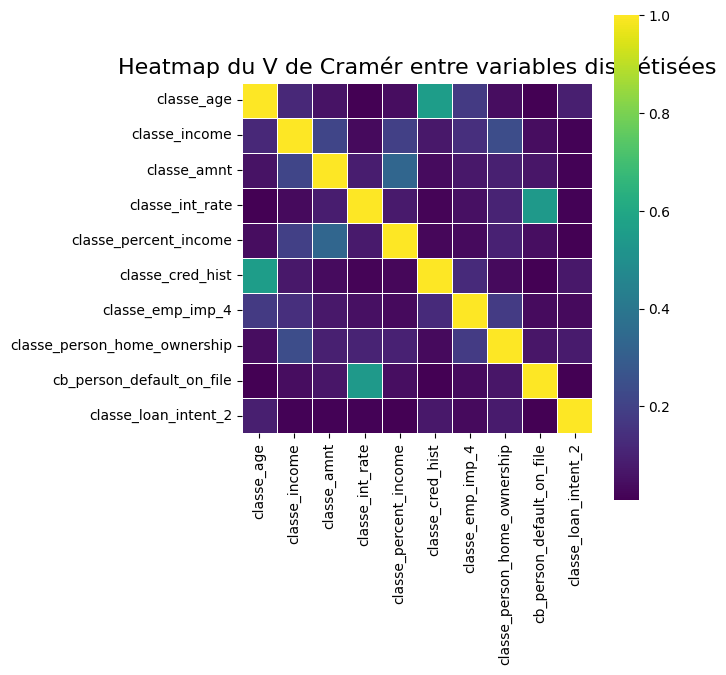

In [40]:
plt.figure(figsize=(7,7))
sns.heatmap(corr_matrix.astype(float),annot=False, cmap="viridis", square=True, linewidths=0.5)
plt.title("Heatmap du V de Cramér entre variables discrétisées", fontsize=16)
plt.tight_layout()
plt.show()

- forte association entre **classe_cred_hist** et **classe_age**
- forte association entre **cb_person_default_on_file** et **classe_int_rate**
- Association modérée entre **classe_person_income** et **classe_amnt**

In [41]:
## On remarque aussi que loan_percent_income = loan_amnt / loan_income (même s'il y'a quelques différences)
df["var"] = round(df["loan_amnt"]/df["person_income"], 2)
df[["var","loan_percent_income"]].head(10)

,var,loan_percent_income
1,0.100,0.100
2,0.570,0.570
3,0.530,0.530
4,0.640,0.550
5,0.250,0.250
6,0.450,0.450
7,0.440,0.440
8,0.420,0.420
9,0.160,0.160
10,0.410,0.410


In [42]:
corr_pearson = df["loan_percent_income"].corr(df["var"], method="pearson")
print("Corrélation de Pearson :", corr_pearson)

Corrélation de Pearson : 0.9992026542037479


In [43]:
results_chi2_loan_status = []
for var in features:
    confusion = pd.crosstab(dff_reg[var], dff_reg[target])
    n = confusion.sum().sum()
    r, k = confusion.shape
    chi2, p, dof, expected = chi2_contingency(confusion)
    v_cramer = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    results_chi2_loan_status.append({
        'variable': var,
        'chi2': chi2,
        'p_value': p,
        'V_de_cramer' : v_cramer
    })
    
results_chi2_loan_status = pd.DataFrame(results_chi2_loan_status)
results_chi2_loan_status

,variable,chi2,p_value,V_de_cramer
0,classe_age,46.836,0.000,0.042
1,classe_income,2674.434,0.000,0.320
2,classe_amnt,406.505,0.000,0.125
3,classe_int_rate,3367.348,0.000,0.359
4,classe_percent_income,5040.382,0.000,0.440
5,classe_cred_hist,15.617,0.000,0.024
6,classe_emp_imp_4,307.422,0.000,0.109
7,classe_person_home_ownership,1521.822,0.000,0.242
8,cb_person_default_on_file,835.478,0.000,0.179
9,classe_loan_intent_2,408.979,0.000,0.125


- **Age** préféré à **cred_hist** *(IV_age > IV_cred_hist)*
- **loan_int_rate** préféré à **cb_person_default_on_file** *(IV_rate > IV_default_on_file)*

In [44]:
# Exportation de la table pour l'utiliser dans R (On fait la regression logistique sur R pour 
## voir clairement la significativité des variables)
dff_reg.to_csv("../data/df_reg.csv", sep=",", index=False, encoding="utf-8")

# ETAPE 4 : Régression Logistique

In [45]:
# Variables retenues pour le modèle
dff_reg = dff[['loan_status','classe_income','classe_int_rate', 'classe_percent_income',
               'classe_emp_imp_4','classe_person_home_ownership','cb_person_default_on_file',
               'classe_loan_intent_2']].copy()

In [46]:
## Base à utiliser pour le suite
dff_reg.to_csv("../data/data.csv", sep=",", index=False, encoding="utf-8")

In [47]:
print(len(df))
len(df_test_set) + len(dff_reg)

32574


32574

In [48]:
dff_reg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 26059 entries, 20061 to 18759
Data columns (total 8 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   loan_status                   26059 non-null  int64 
 1   classe_income                 26059 non-null  object
 2   classe_int_rate               26059 non-null  object
 3   classe_percent_income         26059 non-null  object
 4   classe_emp_imp_4              26059 non-null  object
 5   classe_person_home_ownership  26059 non-null  object
 6   cb_person_default_on_file     26059 non-null  object
 7   classe_loan_intent_2          26059 non-null  object
dtypes: int64(1), object(7)
memory usage: 1.8+ MB


In [49]:
features = dff_reg.select_dtypes(include=['object']).columns
target = "loan_status"
X = dff_reg[features]
y = dff_reg[target]

In [50]:
## VOIR LES COEFS
cat_vars = X.columns.tolist()

ohe = OneHotEncoder(drop='first', sparse_output=False)
X_final = pd.DataFrame(ohe.fit_transform(X[cat_vars]), columns=ohe.get_feature_names_out(cat_vars), index=X.index)

# Ajouter constante pour statsmodels
X_final = sm.add_constant(X_final)

# =============================
# 3. Fit régression logistique
# =============================
logit_model = sm.Logit(y, X_final)
result = logit_model.fit()

# =============================
# 4. Résultats : coefficients, p-values, odds ratio
# =============================
summary_df = pd.DataFrame({
    'variable': result.params.index,
    'coefficient': result.params.values,
    'p_value': result.pvalues,
    'odds_ratio': result.params.apply(lambda x: round(np.exp(x), 3))
}).sort_values(by='coefficient', ascending=False)

summary_df

Optimization terminated successfully.
         Current function value: 0.325918
         Iterations 7


,variable,coefficient,p_value,odds_ratio
"classe_int_rate_[15.28, inf)","classe_int_rate_[15.28, inf)",3.130,0.000,22.871
"classe_percent_income_[0.31, inf)","classe_percent_income_[0.31, inf)",3.077,0.000,21.696
"classe_int_rate_[14.37, 15.28)","classe_int_rate_[14.37, 15.28)",2.399,0.000,11.013
classe_int_rate_Missing,classe_int_rate_Missing,0.890,0.000,2.435
"classe_int_rate_[12.07, 14.37)","classe_int_rate_[12.07, 14.37)",0.889,0.000,2.432
"classe_loan_intent_2_[HOMEIMPROVEMENT, MEDICAL]","classe_loan_intent_2_[HOMEIMPROVEMENT, MEDICAL]",0.854,0.000,2.350
"classe_person_home_ownership_[OTHER, RENT]","classe_person_home_ownership_[OTHER, RENT]",0.817,0.000,2.264
"classe_int_rate_[7.89, 12.07)","classe_int_rate_[7.89, 12.07)",0.440,0.000,1.552
"classe_percent_income_[0.25, 0.31)","classe_percent_income_[0.25, 0.31)",0.392,0.000,1.480
"classe_percent_income_[0.16, 0.25)","classe_percent_income_[0.16, 0.25)",0.258,0.000,1.294


In [51]:
pd.set_option('display.float_format', lambda x: '%.3f' % x)
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import OneHotEncoder
from typing import Dict, Tuple, Any

# =============================================
# 1. Définition des fonctions
# =============================================

def encode_vars(data: pd.DataFrame, features: list, refs: Dict[str, str]) -> pd.DataFrame:
    """One-hot encoding avec références choisies."""
    dfs = []
    for var in features:
        ref = refs[var]
        for mod in data[var].unique():
            if mod != ref:
                dfs.append(pd.DataFrame(
                    {f"{var}_{mod}": (data[var] == mod).astype(int)},
                    index=data.index
                ))
    return pd.concat(dfs, axis=1)

def find_optimal_refs(data: pd.DataFrame, features: list, target: str) -> Tuple[Dict, Any]:
    """Trouve les références qui donnent tous les coefficients négatifs."""
    ohe = OneHotEncoder(drop='first', sparse_output=False)
    X = pd.DataFrame(
        ohe.fit_transform(data[features]),
        columns=ohe.get_feature_names_out(features),
        index=data.index
    )
    model_temp = sm.Logit(data[target], sm.add_constant(X)).fit(disp=0)

    # Trouver les modalités avec coef max par variable
    refs = {}
    for var in features:
        mods = sorted(data[var].unique())
        coefs = {}
        for mod in mods:
            col = f"{var}_{mod}"
            coefs[mod] = model_temp.params.get(col, 0.0)
        refs[var] = max(coefs, key=coefs.get)

    # Régression finale avec les bonnes références
    X_final_refs = encode_vars(data, features, refs)
    model_final = sm.Logit(data[target], sm.add_constant(X_final_refs)).fit(disp=0)

    return refs, model_final

def build_results_table(model, refs: Dict[str, str]) -> pd.DataFrame:
    """Construit le tableau de résultats complet avec les références."""
    df = pd.DataFrame({
        'modalite': model.params.index,
        'coef': model.params.values,
        'pval': model.pvalues.values,
        'OR': np.exp(model.params.values)
    })

    # Ajouter les références
    ref_rows = []
    for v, m in refs.items():
        ref_rows.append({
            'modalite': f"{v}_{m}",
            'coef': 0.0,
            'pval': 0.0,
            'OR': 1.0
        })

    result = pd.concat([df, pd.DataFrame(ref_rows)], ignore_index=True)
    result = result.sort_values('modalite')

    return result[['modalite', 'coef', 'pval', 'OR']]

# =============================================
# 2. Utilisation des fonctions
# =============================================

# Ajoute la variable cible (y) à X pour avoir un DataFrame complet
data = X.assign(loan_status=y)

# Trouve les références optimales et ajuste le modèle
refs, model_refs = find_optimal_refs(data, cat_vars, 'loan_status')

# Affiche les résultats avec références optimales
results_refs = build_results_table(model_refs, refs)
print(f"Nombre de coefficients positifs : {(results_refs['coef'] > 0).sum()}")

# Affichage
print("\n--- Résultats avec références optimales ---")
results_refs


Nombre de coefficients positifs : 1

--- Résultats avec références optimales ---


,modalite,coef,pval,OR
18,cb_person_default_on_file_N,-0.246,0.000,0.782
27,cb_person_default_on_file_Y,0.000,0.000,1.000
25,"classe_emp_imp_4_(-inf, 2.50)",0.000,0.000,1.000
13,"classe_emp_imp_4_[2.50, 4.50)",-0.342,0.000,0.711
14,"classe_emp_imp_4_[4.50, 7.50)",-0.219,0.000,0.803
15,"classe_emp_imp_4_[7.50, inf)",-0.163,0.006,0.850
22,"classe_income_(-inf, 22806.00)",0.000,0.000,1.000
1,"classe_income_[22806.00, 34990.00)",-1.595,0.000,0.203
2,"classe_income_[34990.00, 59853.50)",-2.184,0.000,0.113
4,"classe_income_[59853.50, 79993.50)",-2.471,0.000,0.085


In [52]:
## Validation croisée
from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, confusion_matrix
)
from sklearn.model_selection import cross_val_predict
cat_vars = X.columns.tolist()
preprocess = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), cat_vars)
    ]
)

model = Pipeline(steps=[
    ('preprocess', preprocess),
    ('logreg', LogisticRegression(max_iter=1000,class_weight='balanced', random_state=42))
])
y_train_pred = cross_val_predict(model, X, y, cv=3, method='predict_proba')[:, 1]


In [53]:
# from sklearn.metrics import confusion_matrix
# cm = confusion_matrix(y, y_train_pred)
# print(f'Précision : {precision_score(y, y_train_pred)}')
# print(f'Recall : {recall_score(y, y_train_pred)}')
# print(f'f1_score : {f1_score(y, y_train_pred)}')
print(f'roc_auc_score : {roc_auc_score(y, y_train_pred)}')
# print(f'balanced_accuracy_score : {balanced_accuracy_score(y, y_train_pred)}')

# cm
# ligne : classe réelle; colonne : classe prédite

roc_auc_score : 0.8806689897498878


- On prédit sur le Test_set

In [54]:
thresholds = np.linspace(0.01, 0.99, 50)
results = []
for th in thresholds:
    y_pred = (y_train_pred >= th).astype(int)

    results.append({
        "threshold": th,
        "precision": precision_score(y, y_pred),
        "recall": recall_score(y, y_pred),
        "f1": f1_score(y, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y, y_pred)
    })

df_results = pd.DataFrame(results)


In [55]:
# plt.plot(df_results.threshold, df_results.precision, label="Precision")
# plt.plot(df_results.threshold, df_results.recall, label="Recall")
# plt.plot(df_results.threshold, df_results.f1, label="F1")
# plt.plot(df_results.threshold, df_results.balanced_accuracy, label="Balanced Accuracy")

# plt.xlabel("Seuil")
# plt.ylabel("Score")
# plt.legend()
# plt.grid(True)
# plt.show()

In [56]:
# meilleur seuil pour la balance accuracy
best_bal_acc = df_results.loc[df_results.balanced_accuracy.idxmax()]
print("Meilleur seuil (Balanced Acc):", best_bal_acc.threshold)
print(best_bal_acc)

Meilleur seuil (Balanced Acc): 0.53
threshold           0.530
precision           0.598
recall              0.756
f1                  0.668
balanced_accuracy   0.807
Name: 26, dtype: float64


- On va considérer le seuil 0.50

In [57]:
test = df_test_set.copy()
# test.to_csv("../data/test_set.csv", sep=",", index=False, encoding="utf-8")

In [58]:
## On applique toute les transformation du train_set au test_set
test = cat_age(test, 3) 
test = cat_income(test)  
test = cat_amnt(test)
test = cat_int_rate(test) 
test = cat_percent_income(test)
test = cat_cred_hist_length(test)
test = cat_home_ownership(test)
test = cat_loan_intent_2(test)

test["emp_imputed"] = test.apply(impute_emp, axis=1)

test = cat_emp_length_imputed(test, 4)

test_reg = test[['loan_status','classe_income','classe_int_rate', 'classe_percent_income',
               'classe_emp_imp_4','classe_person_home_ownership','cb_person_default_on_file',
               'classe_loan_intent_2']].copy()

In [59]:
X_test = test_reg[features]
y_test = test_reg[target]
model.fit(X, y)
y_test_proba = model.predict_proba(X_test)[:, 1]
y_test_pred = (y_test_proba >= 0.5).astype(int)
y_train_proba = model.predict_proba(X)[:, 1]
y_train_pred = (y_train_proba >= 0.5).astype(int)

In [60]:
## Performance sur le Train_set
print("Balanced Accuracy :", balanced_accuracy_score(y, y_train_pred))
print("Precision :", precision_score(y, y_train_pred))
print("Recall :", recall_score(y, y_train_pred))  # Objectif métier habituel : 70–80%
print("F1-score :", f1_score(y, y_train_pred))
print("ROC AUC :", roc_auc_score(y, y_train_proba))

print("\nConfusion Matrix :")
print(confusion_matrix(y, y_train_pred))

Balanced Accuracy : 0.806709143727312
Precision : 0.577892098667722
Recall : 0.7704889201547661
F1-score : 0.6604356674455416
ROC AUC : 0.8816903476853828

Confusion Matrix :
[[17173  3200]
 [ 1305  4381]]


In [61]:
## Performance sur le Test_set
print("Balanced Accuracy :", balanced_accuracy_score(y_test, y_test_pred))
print("Precision :", precision_score(y_test, y_test_pred))
print("Recall :", recall_score(y_test, y_test_pred))  # Objectif métier habituel : 70–80%
print("F1-score :", f1_score(y_test, y_test_pred))
print("ROC AUC :", roc_auc_score(y_test, y_test_proba))

print("\nConfusion Matrix :")
print(confusion_matrix(y_test, y_test_pred))

Balanced Accuracy : 0.8079295037945319
Precision : 0.5832443970117396
Recall : 0.7691766361717101
F1-score : 0.6634294385432473
ROC AUC : 0.8868945734339388

Confusion Matrix :
[[4313  781]
 [ 328 1093]]


- Gini ≈ 0.77 (calcul rapide : 2 * AUC - 1) ce qui signifie un bon pouvoir de discrimination.

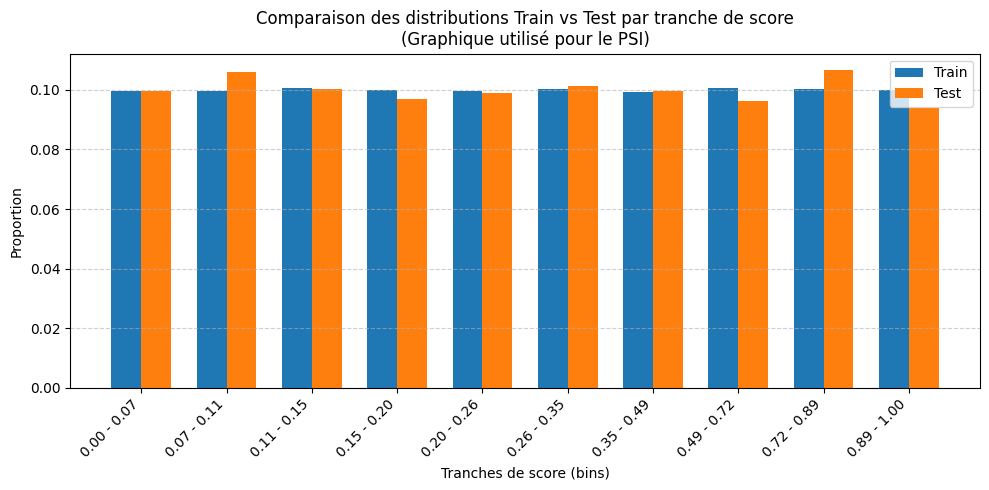

PSI score : 0.0015330817123569355


In [62]:
## Calcul du PSI : Il mesure la stabilité des scores (probabilités) entre Train  (période d’entraînement) et Test (nouvelle population que tu veux valider)
def plot_psi_chart(train_proba, test_proba, bins=10):
    # 1. Créer les bins selon les percentiles du train
    breakpoints = np.percentile(train_proba, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)

    # 2. Calculer les distributions
    train_counts, _ = np.histogram(train_proba, bins=breakpoints)
    test_counts, _ = np.histogram(test_proba, bins=breakpoints)

    train_perc = train_counts / len(train_proba)
    test_perc = test_counts / len(test_proba)

    # Pour affichage
    bin_labels = []
    for i in range(len(breakpoints) - 1):
        bin_labels.append(f"{breakpoints[i]:.2f} - {breakpoints[i+1]:.2f}")

    x = np.arange(len(train_perc))  # positions des bins
    width = 0.35

    # 3. Tracé du graphique
    plt.figure(figsize=(10, 5))
    plt.bar(x - width/2, train_perc, width, label='Train')
    plt.bar(x + width/2, test_perc, width, label='Test')

    plt.xticks(x, bin_labels, rotation=45, ha='right')
    plt.ylabel("Proportion")
    plt.xlabel("Tranches de score (bins)")
    plt.title("Comparaison des distributions Train vs Test par tranche de score\n(Graphique utilisé pour le PSI)")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

# --- Utilisation ---
plot_psi_chart(y_train_proba, y_test_proba, bins=10)


def calculate_psi(expected, actual, bins=10):
    # Découpage selon les percentiles de la population train ("expected")
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins+1))
    breakpoints = np.unique(breakpoints)  # éviter les bins identiques

    # Histogrammes
    expected_counts, _ = np.histogram(expected, bins=breakpoints)
    actual_counts, _ = np.histogram(actual, bins=breakpoints)

    # Convertir en proportions
    expected_perc = expected_counts / len(expected)
    actual_perc = actual_counts / len(actual)

    # Éviter division par zéro
    expected_perc = np.where(expected_perc == 0, 1e-8, expected_perc)
    actual_perc = np.where(actual_perc == 0, 1e-8, actual_perc)

    # PSI
    psi = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
    return psi

psi_value = calculate_psi(y_train_proba, y_test_proba, bins=10)
print("PSI score :", psi_value)

- Population stable (PSI < 0.1)

#### Scorecard Bancaire

Une scorecard bancaire transforme les probabilités prédites par le modèle en points (souvent 0–1000) pour :

- faciliter la lecture par les analystes métiers

- intégrer un cadre réglementaire (Bâle II/III)

- comparer différents clients sur une échelle commune

# Etape 5 : Grille de Score

### 1. Séparer variable / classe

Objcetif : Transformer la sortie brute de la régression logistique en un tableau exploitable pour la scorecard, en identifiant clairement :

- le nom de la variable
- la modalité associée
- le coefficient estimé
- la significativité
- l’odds ratio

In [63]:
def build_results_table(model) -> pd.DataFrame:
    """Tableau des coefficients SANS doublons."""

    result = pd.DataFrame({
        'modalite': model.params.index,
        'coef': model.params.values,
        'pval': model.pvalues.values,
        'OR': np.exp(model.params.values)
    })

    return result.sort_values('modalite')

score_df = results_refs.copy()

score_df[['variable', 'classe']] = (
    score_df['modalite']
    .str.rsplit('_', n=1, expand=True)
)


In [64]:
score_df

,modalite,coef,pval,OR,variable,classe
18,cb_person_default_on_file_N,-0.246,0.000,0.782,cb_person_default_on_file,N
27,cb_person_default_on_file_Y,0.000,0.000,1.000,cb_person_default_on_file,Y
25,"classe_emp_imp_4_(-inf, 2.50)",0.000,0.000,1.000,classe_emp_imp_4,"(-inf, 2.50)"
13,"classe_emp_imp_4_[2.50, 4.50)",-0.342,0.000,0.711,classe_emp_imp_4,"[2.50, 4.50)"
14,"classe_emp_imp_4_[4.50, 7.50)",-0.219,0.000,0.803,classe_emp_imp_4,"[4.50, 7.50)"
15,"classe_emp_imp_4_[7.50, inf)",-0.163,0.006,0.850,classe_emp_imp_4,"[7.50, inf)"
22,"classe_income_(-inf, 22806.00)",0.000,0.000,1.000,classe_income,"(-inf, 22806.00)"
1,"classe_income_[22806.00, 34990.00)",-1.595,0.000,0.203,classe_income,"[22806.00, 34990.00)"
2,"classe_income_[34990.00, 59853.50)",-2.184,0.000,0.113,classe_income,"[34990.00, 59853.50)"
4,"classe_income_[59853.50, 79993.50)",-2.471,0.000,0.085,classe_income,"[59853.50, 79993.50)"


Objectif : Transformer les données au format individu (ligne = client)
en un format long (ligne = variable–modalité) afin de pouvoir :

- calculer le taux de défaut par classe
- calculer les effectifs par classe
- vérifier la cohérence économique du score
- fusionner ces statistiques avec la grille de score

Chaque client génère une ligne par variable.

Les données sont restructurées au format long afin de permettre une analyse par variable et par modalité. Cette transformation est nécessaire pour calculer les taux de défaut et les effectifs associés à chaque classe utilisée dans la scorecard.

In [65]:
long_df = data.melt(
    id_vars='loan_status',
    value_vars=cat_vars,
    var_name='variable',
    value_name='classe'
)

In [66]:
set(score_df['variable']) - set(long_df['variable'])

{'const'}

In [67]:
long_df

,loan_status,variable,classe
0,0,classe_income,"[22806.00, 34990.00)"
1,0,classe_income,"[34990.00, 59853.50)"
2,0,classe_income,"[79993.50, inf)"
3,0,classe_income,"[34990.00, 59853.50)"
4,0,classe_income,"[79993.50, inf)"
...,...,...,...
182408,0,classe_loan_intent_2,PERSONAL
182409,1,classe_loan_intent_2,VENTURE
182410,0,classe_loan_intent_2,"[HOMEIMPROVEMENT, MEDICAL]"
182411,0,classe_loan_intent_2,PERSONAL


### 2. Calcul des bornes β par variable

**Objectif : Associer à chaque modalité de chaque variable :**

- son taux de défaut observé
- son poids dans la population

afin de :

- vérifier la cohérence économique du modèle
- documenter la grille de score finale
- permettre l’interprétation métier

⚠️ Ces statistiques ne servent pas à estimer le modèle,
elles servent à le valider et l’expliquer.

In [68]:
stats = (
    long_df
    .groupby(['variable', 'classe'])
    .agg(
        taux_defaut=('loan_status', 'mean'),
        effectif=('loan_status', 'size')
    )
    .reset_index()
)

stats['taux_defaut_pct'] = 100 * stats['taux_defaut']
stats['effectif_pct'] = 100 * stats['effectif'] / len(data)

score_df = score_df.merge(
    stats[['variable','classe','taux_defaut_pct','effectif_pct']],
    on=['variable','classe'],
    how='left',
    validate='one_to_one'
)


### 3. Calcul du dénominateur global

La note associée à la modalité $j$ de la variable $i$ est définie comme :

$$
N_i^j
=
\frac{\left|\max\left(\beta_i^1,\dots,\beta_i^p\right) - \beta_i^j\right|}
{\sum_{k=1}^{K}
\left[
\max\left(\beta_k^1,\dots,\beta_k^p\right)
-
\min\left(\beta_k^1,\dots,\beta_k^p\right)
\right]}
\times 1000
$$

où :

- $\beta_i^j$ est le coefficient estimé par la régression logistique pour la modalité $j$ de la variable $i$ ;
- $\max(\beta_i^1,\dots,\beta_i^p)$ est le coefficient maximal de la variable $i$ ;
- $\min(\beta_i^1,\dots,\beta_i^p)$ est le coefficient minimal de la variable $i$ ;
- $p$ est le nombre de modalités de la variable $i$ ;
- $K$ est le nombre de variables du modèle ;
- $N_i^j \in [0,1000]$, avec $0$ correspondant au profil le moins risqué et $1000$ au profil le plus risqué.


In [69]:
beta_stats = (
    score_df
    .groupby('variable')['coef']
    .agg(beta_min='min', beta_max='max')
    .reset_index()
)

score_df = score_df.merge(beta_stats, on='variable', how='left')
denominator = (beta_stats['beta_max'] - beta_stats['beta_min']).sum()


### 4. Calcul de la NOTE (0 = pas risqué, 1000 = très risqué)

**Objectif :**

Transformer les coefficients logistiques estimés par le modèle en points de score compris entre 0 et 1000, selon l’amplitude de risque de chaque variable.

On finit la formule du dessus en gros

In [70]:
score_df['note'] = (
    (score_df['coef'] - score_df['beta_min']) / denominator * 1000
).clip(0, 1000)


### 5. Taux de défaut et effectifs par classe

In [71]:
freq = (
    long_df
    .groupby(['variable', 'classe'])
    .size()
    .div(len(data))
    .reset_index(name='rj')
)


score_df = score_df.merge(
    freq,
    on=['variable','classe'],
    how='left',
    validate='one_to_one'
)


### 6. Fusion score + stats (grille finale)

In [72]:
scorecard = score_df.merge(
    stats[['variable', 'classe', 'taux_defaut_pct', 'effectif_pct']],
    on=['variable', 'classe'],
    how='left'
)

### 8. Contribution

La contribution de la variable $i$ au score total est définie comme :

$$
c_i
=
\frac{
\sqrt{
\sum_{j=1}^{p}
r_j
\left(
N_i^j - \bar{N}_i
\right)^2
}
}{
\sum_{k=1}^{K}
\sqrt{
\sum_{j=1}^{p}
r_j
\left(
N_k^j - \bar{N}_k
\right)^2
}
}
$$

où :

- $N_i^j$ est la note associée à la modalité $j$ de la variable $i$ ;
- $\bar{N}_i$ est la note moyenne de la variable $i$ ;
- $r_j$ est la proportion de la population appartenant à la modalité $j$ de la variable $i$ ;
- $p$ est le nombre de modalités de la variable $i$ ;
- $K$ est le nombre de variables du modèle.


In [73]:
def weighted_mean(x, w):
    return (x * w).sum() / w.sum()

dispersion = {}
for var, dfv in score_df.groupby('variable'):
    w = dfv['rj'].fillna(0)
    n = dfv['note']
    if w.sum() == 0:
        disp = 0
    else:
        n_bar = weighted_mean(n, w)
        disp = np.sqrt((w * (n - n_bar)**2).sum())
    dispersion[var] = disp

total_disp = sum(dispersion.values())

score_df['contribution'] = score_df['variable'].map(
    lambda v: dispersion[v] / total_disp if total_disp > 0 else 0
)


In [74]:
def signif(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

score_df['signif'] = score_df['pval'].apply(signif)


In [75]:
print(score_df.columns)

Index(['modalite', 'coef', 'pval', 'OR', 'variable', 'classe',
       'taux_defaut_pct', 'effectif_pct', 'beta_min', 'beta_max', 'note', 'rj',
       'contribution', 'signif'],
      dtype='object')


### 8. Grille de score finale (PJ1)

In [76]:
final_scorecard = (
    score_df
    .sort_values(['variable','note'])
    [['variable','classe','signif','note',
      'taux_defaut_pct','effectif_pct','contribution']]
)

final_scorecard.groupby(['variable','classe']).size().max()


np.int64(1)

In [77]:
final_scorecard

,variable,classe,signif,note,taux_defaut_pct,effectif_pct,contribution
0,cb_person_default_on_file,N,***,0.000,18.397,82.375,0.024
1,cb_person_default_on_file,Y,***,18.257,37.818,17.625,0.024
3,classe_emp_imp_4,"[2.50, 4.50)",***,0.000,20.745,20.922,0.032
4,classe_emp_imp_4,"[4.50, 7.50)",***,9.097,18.734,24.847,0.032
5,classe_emp_imp_4,"[7.50, inf)",**,13.271,16.720,20.404,0.032
2,classe_emp_imp_4,"(-inf, 2.50)",***,25.316,27.828,33.827,0.032
10,classe_income,"[79993.50, inf)",***,0.000,8.922,24.817,0.159
9,classe_income,"[59853.50, 79993.50)",***,23.256,15.265,20.891,0.159
8,classe_income,"[34990.00, 59853.50)",***,44.477,22.304,35.082,0.159
7,classe_income,"[22806.00, 34990.00)",***,88.120,38.091,14.195,0.159


**Score individuel :**


Pour chaque individu, le score total est calculé comme la somme des notes associées aux modalités observées pour chacune des variables de la grille de score :

$$
\text{Score}(x) = \sum_{i=1}^{K} N_i^{\,j(x)}
$$

où :

- $i$ désigne la variable explicative (par exemple : revenu, taux d’intérêt, ratio d’endettement, etc.)
- $j(x)$ correspond à la modalité (classe) de la variable $i$ à laquelle appartient l’individu $x$
- $N_i^{\,j}$ est la note attribuée à la modalité $j$ de la variable $i$ dans la grille de score
- $K$ est le nombre total de variables utilisées dans le modèle

Ce mécanisme correspond au principe d’une **scorecard additive** : chaque variable contribue de manière indépendante au score final, et le score global est obtenu par sommation des contributions individuelles.


In [113]:
final_scorecard

,variable,classe,signif,note,taux_defaut_pct,effectif_pct,contribution
0,cb_person_default_on_file,N,***,0.000,18.397,82.375,0.024
1,cb_person_default_on_file,Y,***,18.257,37.818,17.625,0.024
3,classe_emp_imp_4,"[2.50, 4.50)",***,0.000,20.745,20.922,0.032
4,classe_emp_imp_4,"[4.50, 7.50)",***,9.097,18.734,24.847,0.032
5,classe_emp_imp_4,"[7.50, inf)",**,13.271,16.720,20.404,0.032
2,classe_emp_imp_4,"(-inf, 2.50)",***,25.316,27.828,33.827,0.032
10,classe_income,"[79993.50, inf)",***,0.000,8.922,24.817,0.159
9,classe_income,"[59853.50, 79993.50)",***,23.256,15.265,20.891,0.159
8,classe_income,"[34990.00, 59853.50)",***,44.477,22.304,35.082,0.159
7,classe_income,"[22806.00, 34990.00)",***,88.120,38.091,14.195,0.159


In [78]:
score_dict = (
    final_scorecard
    .set_index(['variable', 'classe'])['note']
    .to_dict()
)

def compute_score(df, cat_vars, score_dict):
    scores = []
    
    for _, row in df.iterrows():
        s = 0
        for var in cat_vars:
            key = (var, row[var])
            s += score_dict.get(key, 0)
        scores.append(s)
    
    return pd.Series(scores, index=df.index)


In [79]:
X_train = dff_reg[features]

In [115]:
score_train = compute_score(X_train, cat_vars, score_dict)
score_test  = compute_score(X_test,  cat_vars, score_dict)

In [81]:
score_train.describe()
score_test.describe()

count   6515.000
mean     368.812
std      143.299
min       13.271
25%      272.898
50%      345.933
75%      444.129
max     1000.000
dtype: float64

### ETAPE 6 : VERIFICATION GRAPHIQUE

In [82]:
def compute_psi(train, test, bins=10):
    breakpoints = np.percentile(train, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)

    train_counts, _ = np.histogram(train, bins=breakpoints)
    test_counts, _ = np.histogram(test, bins=breakpoints)

    train_perc = train_counts / train_counts.sum()
    test_perc = test_counts / test_counts.sum()

    psi = np.sum(
        (train_perc - test_perc) *
        np.log((train_perc + 1e-6) / (test_perc + 1e-6))
    )
    return psi
psi_score = compute_psi(score_train, score_test)


In [83]:
print(round(psi_score,5))

0.00171


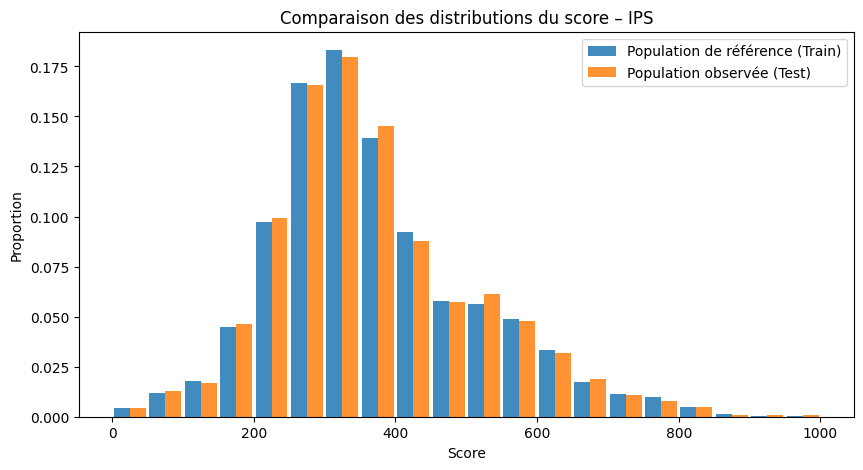

In [84]:
# Bins fixes (ex : 20 classes)
bins = np.linspace(0, 1000, 21)

train_counts, _ = np.histogram(score_train, bins=bins)
test_counts, _ = np.histogram(score_test, bins=bins)

train_prop = train_counts / train_counts.sum()
test_prop = test_counts / test_counts.sum()

bin_centers = (bins[:-1] + bins[1:]) / 2
bin_width = bins[1] - bins[0]

bar_width = bin_width * 0.45   # <- clé pour les espaces
offset = bar_width / 2

plt.figure(figsize=(10,5))

plt.bar(
    bin_centers - offset,
    train_prop,
    width=bar_width,
    label='Population de référence (Train)',
    alpha=0.85
)

plt.bar(
    bin_centers + offset,
    test_prop,
    width=bar_width,
    label='Population observée (Test)',
    alpha=0.85
)

plt.xlabel('Score')
plt.ylabel('Proportion')
plt.title('Comparaison des distributions du score – IPS')
plt.legend()
plt.show()


In [85]:
def lorenz_curve(y_true, score):
    df = pd.DataFrame({
        'y': y_true,
        'score': score
    }).sort_values('score')

    df['cum_population'] = np.arange(1, len(df) + 1) / len(df)
    df['cum_defaults'] = df['y'].cumsum() / df['y'].sum()

    return df['cum_population'], df['cum_defaults']

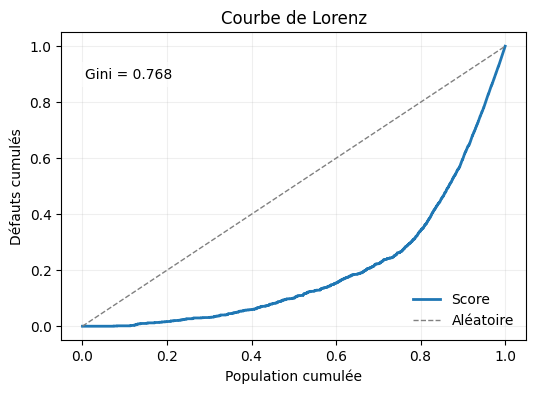

In [86]:
from sklearn.metrics import roc_auc_score

# Calcul Gini
auc = roc_auc_score(y_test, score_test)
gini = 2 * auc - 1

cum_pop, cum_def = lorenz_curve(y_test, score_test)

plt.figure(figsize=(6,4))

# Courbe de Lorenz
plt.plot(
    cum_pop,
    cum_def,
    color='#1f77b4',
    linewidth=2,
    label='Score'
)

# Diagonale aléatoire
plt.plot(
    [0, 1],
    [0, 1],
    color='gray',
    linestyle='--',
    linewidth=1,
    label='Aléatoire'
)

plt.xlabel('Population cumulée')
plt.ylabel('Défauts cumulés')
plt.title('Courbe de Lorenz')

# Texte Gini dans le graphique
plt.text(
    0.05, 0.85,
    f"Gini = {gini:.3f}",
    transform=plt.gca().transAxes,
    fontsize=10,
    bbox=dict(facecolor='white', alpha=0.6, edgecolor='none')
)

plt.legend(frameon=False)
plt.grid(alpha=0.2)
plt.show()


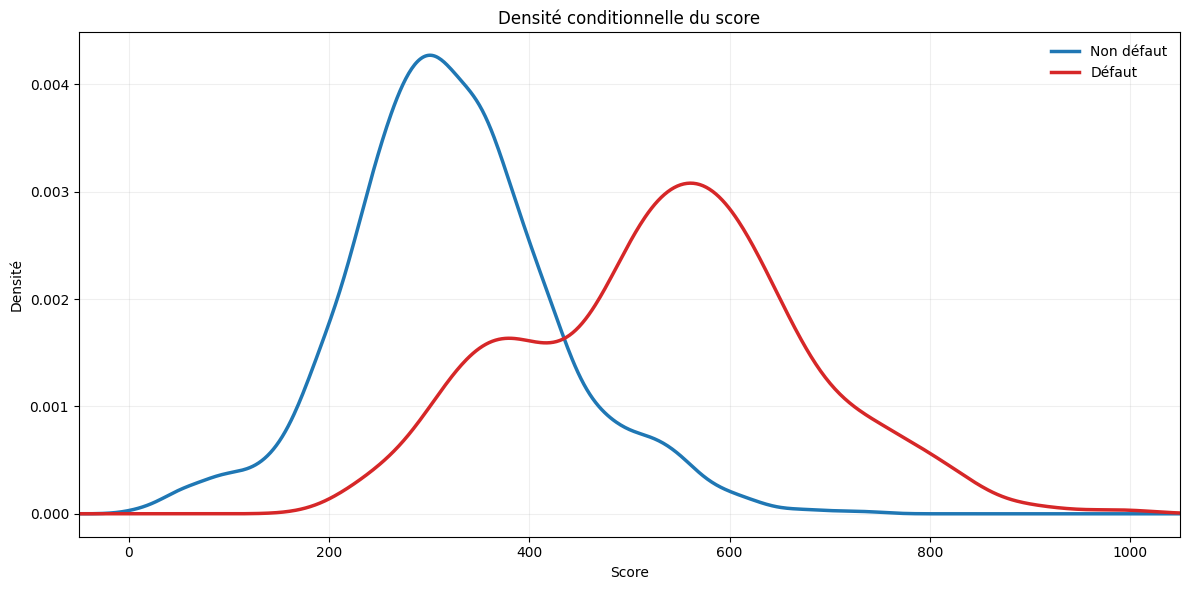

In [87]:
plt.figure(figsize=(12,6))

# Non défaut
score_test[y_test == 0].plot(
    kind='density',
    linewidth=2.5,
    color='#1f77b4',      # bleu propre
    label='Non défaut'
)

# Défaut
score_test[y_test == 1].plot(
    kind='density',
    linewidth=2.5,
    color='#d62728',      # rouge sobre
    label='Défaut'
)

plt.xlim(-50, 1050)
plt.xlabel('Score')
plt.ylabel('Densité')
plt.title('Densité conditionnelle du score')
plt.legend(frameon=False)
plt.grid(alpha=0.2)

plt.tight_layout()
plt.show()


In [88]:
score_test[y_test == 0].max() # Un individu qui a fait defaut avec 747 en max

np.float64(747.3072009930306)

### ETAPE 7 : SEGMENTATION

In [89]:
# =============================================
# Segmentation du score en Classes Homogènes de Risque (CHR)
# =============================================

# 1. Paramètre : nombre de classes de risque
n_classes = 7

# 2. Construction du DataFrame score + cible
df_seg = pd.DataFrame({
    'score': score_test,
    'loan_status': y_test
})

# 3. Découpage du score en CHR (quantiles)
df_seg['CHR'] = pd.qcut(
    df_seg['score'],
    q=n_classes,
    labels=[f'CHR{i+1}' for i in range(n_classes)]
)

# 4. Statistiques par classe de risque
chr_stats = (
    df_seg
    .groupby('CHR')
    .agg(
        effectif=('loan_status', 'size'),
        effectif_pct=('loan_status', lambda x: 100 * len(x) / len(df_seg)),
        taux_defaut=('loan_status', 'mean')
    )
    .reset_index()
)

chr_stats['taux_defaut_pct'] = 100 * chr_stats['taux_defaut']

# 5. Affichage des résultats
chr_stats


/tmp/ipykernel_148782/360146630.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('CHR')


,CHR,effectif,effectif_pct,taux_defaut,taux_defaut_pct
0,CHR1,942,14.459,0.015,1.486
1,CHR2,920,14.121,0.033,3.261
2,CHR3,930,14.275,0.061,6.129
3,CHR4,931,14.290,0.100,9.989
4,CHR5,931,14.290,0.155,15.467
5,CHR6,931,14.290,0.365,36.520
6,CHR7,930,14.275,0.799,79.892


## Test sur tout le dataset

In [118]:
X_combined = pd.concat([X_train, X_test], ignore_index=True)

In [119]:
X_combined 

,classe_income,classe_int_rate,classe_percent_income,classe_emp_imp_4,classe_person_home_ownership,cb_person_default_on_file,classe_loan_intent_2
0,"[22806.00, 34990.00)","[7.89, 12.07)","(-inf, 0.16)","[2.50, 4.50)","[OTHER, RENT]",N,VENTURE
1,"[34990.00, 59853.50)","(-inf, 7.89)","[0.16, 0.25)","(-inf, 2.50)","[OTHER, RENT]",N,PERSONAL
2,"[79993.50, inf)","[7.89, 12.07)","[0.16, 0.25)","[4.50, 7.50)","[OTHER, RENT]",N,"[HOMEIMPROVEMENT, MEDICAL]"
3,"[34990.00, 59853.50)","[14.37, 15.28)","[0.31, inf)","[2.50, 4.50)",MORTGAGE,Y,EDUCATION
4,"[79993.50, inf)","(-inf, 7.89)","(-inf, 0.16)","[7.50, inf)",MORTGAGE,N,"[HOMEIMPROVEMENT, MEDICAL]"
...,...,...,...,...,...,...,...
32569,"[34990.00, 59853.50)",Missing,"(-inf, 0.16)","[2.50, 4.50)","[OTHER, RENT]",N,VENTURE
32570,"[79993.50, inf)",Missing,"(-inf, 0.16)","[2.50, 4.50)",MORTGAGE,N,"[HOMEIMPROVEMENT, MEDICAL]"
32571,"[59853.50, 79993.50)","(-inf, 7.89)","[0.16, 0.25)","[2.50, 4.50)","[OTHER, RENT]",N,"[HOMEIMPROVEMENT, MEDICAL]"
32572,"[59853.50, 79993.50)","[15.28, inf)","[0.31, inf)","[7.50, inf)",OWN,Y,PERSONAL


In [123]:
X_combined = X_combined.reset_index().rename(columns={'index': 'id'})

In [126]:
X_combined 

,id,classe_income,classe_int_rate,classe_percent_income,classe_emp_imp_4,classe_person_home_ownership,cb_person_default_on_file,classe_loan_intent_2
0,0,"[22806.00, 34990.00)","[7.89, 12.07)","(-inf, 0.16)","[2.50, 4.50)","[OTHER, RENT]",N,VENTURE
1,1,"[34990.00, 59853.50)","(-inf, 7.89)","[0.16, 0.25)","(-inf, 2.50)","[OTHER, RENT]",N,PERSONAL
2,2,"[79993.50, inf)","[7.89, 12.07)","[0.16, 0.25)","[4.50, 7.50)","[OTHER, RENT]",N,"[HOMEIMPROVEMENT, MEDICAL]"
3,3,"[34990.00, 59853.50)","[14.37, 15.28)","[0.31, inf)","[2.50, 4.50)",MORTGAGE,Y,EDUCATION
4,4,"[79993.50, inf)","(-inf, 7.89)","(-inf, 0.16)","[7.50, inf)",MORTGAGE,N,"[HOMEIMPROVEMENT, MEDICAL]"
...,...,...,...,...,...,...,...,...
32569,32569,"[34990.00, 59853.50)",Missing,"(-inf, 0.16)","[2.50, 4.50)","[OTHER, RENT]",N,VENTURE
32570,32570,"[79993.50, inf)",Missing,"(-inf, 0.16)","[2.50, 4.50)",MORTGAGE,N,"[HOMEIMPROVEMENT, MEDICAL]"
32571,32571,"[59853.50, 79993.50)","(-inf, 7.89)","[0.16, 0.25)","[2.50, 4.50)","[OTHER, RENT]",N,"[HOMEIMPROVEMENT, MEDICAL]"
32572,32572,"[59853.50, 79993.50)","[15.28, inf)","[0.31, inf)","[7.50, inf)",OWN,Y,PERSONAL


In [124]:
score_all = compute_score(X_combined , cat_vars, score_dict)

In [125]:
score_all 

0       328.791
1       333.129
2       350.979
3       634.850
4       242.950
          ...  
32569   318.517
32570   295.612
32571   332.573
32572   550.807
32573   699.616
Length: 32574, dtype: float64

In [130]:
def compute_score_df(df, cat_vars, score_dict, score_col_name='score'):
    """
    Calcule les scores et les ajoute au DataFrame
    
    Parameters:
    -----------
    df : DataFrame
        DataFrame contenant les variables catégorielles
    cat_vars : list
        Liste des variables catégorielles à utiliser
    score_dict : dict
        Dictionnaire des scores avec clés (variable, valeur)
    score_col_name : str
        Nom de la colonne score (défaut: 'score')
    
    Returns:
    --------
    DataFrame avec la colonne score ajoutée
    """
    scores = []
    
    for _, row in df.iterrows():
        s = 0
        for var in cat_vars:
            key = (var, row[var])
            s += score_dict.get(key, 0)
        scores.append(s)
    df_with_scores = df.copy()
    df_with_scores[score_col_name] = scores
    
    return df_with_scores

In [141]:
score_all = compute_score_df(X_combined , cat_vars, score_dict)

In [142]:
score_all 

,id,classe_income,classe_int_rate,classe_percent_income,classe_emp_imp_4,classe_person_home_ownership,cb_person_default_on_file,classe_loan_intent_2,score
0,0,"[22806.00, 34990.00)","[7.89, 12.07)","(-inf, 0.16)","[2.50, 4.50)","[OTHER, RENT]",N,VENTURE,328.791
1,1,"[34990.00, 59853.50)","(-inf, 7.89)","[0.16, 0.25)","(-inf, 2.50)","[OTHER, RENT]",N,PERSONAL,333.129
2,2,"[79993.50, inf)","[7.89, 12.07)","[0.16, 0.25)","[4.50, 7.50)","[OTHER, RENT]",N,"[HOMEIMPROVEMENT, MEDICAL]",350.979
3,3,"[34990.00, 59853.50)","[14.37, 15.28)","[0.31, inf)","[2.50, 4.50)",MORTGAGE,Y,EDUCATION,634.850
4,4,"[79993.50, inf)","(-inf, 7.89)","(-inf, 0.16)","[7.50, inf)",MORTGAGE,N,"[HOMEIMPROVEMENT, MEDICAL]",242.950
...,...,...,...,...,...,...,...,...,...
32569,32569,"[34990.00, 59853.50)",Missing,"(-inf, 0.16)","[2.50, 4.50)","[OTHER, RENT]",N,VENTURE,318.517
32570,32570,"[79993.50, inf)",Missing,"(-inf, 0.16)","[2.50, 4.50)",MORTGAGE,N,"[HOMEIMPROVEMENT, MEDICAL]",295.612
32571,32571,"[59853.50, 79993.50)","(-inf, 7.89)","[0.16, 0.25)","[2.50, 4.50)","[OTHER, RENT]",N,"[HOMEIMPROVEMENT, MEDICAL]",332.573
32572,32572,"[59853.50, 79993.50)","[15.28, inf)","[0.31, inf)","[7.50, inf)",OWN,Y,PERSONAL,550.807


In [143]:
score_all['cb_person_default_on_file'] = score_all['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

In [144]:
score_all 

,id,classe_income,classe_int_rate,classe_percent_income,classe_emp_imp_4,classe_person_home_ownership,cb_person_default_on_file,classe_loan_intent_2,score
0,0,"[22806.00, 34990.00)","[7.89, 12.07)","(-inf, 0.16)","[2.50, 4.50)","[OTHER, RENT]",0,VENTURE,328.791
1,1,"[34990.00, 59853.50)","(-inf, 7.89)","[0.16, 0.25)","(-inf, 2.50)","[OTHER, RENT]",0,PERSONAL,333.129
2,2,"[79993.50, inf)","[7.89, 12.07)","[0.16, 0.25)","[4.50, 7.50)","[OTHER, RENT]",0,"[HOMEIMPROVEMENT, MEDICAL]",350.979
3,3,"[34990.00, 59853.50)","[14.37, 15.28)","[0.31, inf)","[2.50, 4.50)",MORTGAGE,1,EDUCATION,634.850
4,4,"[79993.50, inf)","(-inf, 7.89)","(-inf, 0.16)","[7.50, inf)",MORTGAGE,0,"[HOMEIMPROVEMENT, MEDICAL]",242.950
...,...,...,...,...,...,...,...,...,...
32569,32569,"[34990.00, 59853.50)",Missing,"(-inf, 0.16)","[2.50, 4.50)","[OTHER, RENT]",0,VENTURE,318.517
32570,32570,"[79993.50, inf)",Missing,"(-inf, 0.16)","[2.50, 4.50)",MORTGAGE,0,"[HOMEIMPROVEMENT, MEDICAL]",295.612
32571,32571,"[59853.50, 79993.50)","(-inf, 7.89)","[0.16, 0.25)","[2.50, 4.50)","[OTHER, RENT]",0,"[HOMEIMPROVEMENT, MEDICAL]",332.573
32572,32572,"[59853.50, 79993.50)","[15.28, inf)","[0.31, inf)","[7.50, inf)",OWN,1,PERSONAL,550.807


In [145]:
# =============================================
# Segmentation du score en Classes Homogènes de Risque (CHR)
# =============================================

# 1. Paramètre : nombre de classes de risque
n_classes = 7

# 3. Construction du DataFrame avec le score et la cible
df_seg = pd.DataFrame({
    'score': score_all['score'],
    'loan_status': score_all['cb_person_default_on_file']
})

# 4. Découpage du score en CHR (quantiles)
df_seg['CHR'] = pd.qcut(
    df_seg['score'],
    q=n_classes,
    labels=[f'CHR{i+1}' for i in range(n_classes)]
)

# 5. Statistiques par classe de risque - CORRIGÉ
chr_stats = df_seg.groupby('CHR').agg(
    effectif=('loan_status', 'size'),
    effectif_pct=('loan_status', lambda x: 100 * len(x) / len(df_seg)),
    taux_defaut=('loan_status', lambda x: x.astype(float).mean()),  # Conversion explicite
    score_min=('score', 'min'),
    score_max=('score', 'max'),
    score_moyen=('score', 'mean')
).reset_index()

chr_stats['taux_defaut_pct'] = 100 * chr_stats['taux_defaut']

# 6. Ajouter la colonne CHR au dataset original
score_all['CHR'] = df_seg['CHR']

# 7. Affichage des résultats
print("Statistiques par Classe Homogène de Risque (CHR):")
print(chr_stats)

print(f"\nDataset avec CHR ajouté - aperçu:")
print(score_all[['id', 'score', 'cb_person_default_on_file', 'CHR']].head())

Statistiques par Classe Homogène de Risque (CHR):
    CHR  effectif  effectif_pct  taux_defaut  score_min  score_max  \
0  CHR1      4675        14.352        0.041      0.000    237.870   
1  CHR2      4651        14.278        0.065    238.041    284.808   
2  CHR3      4659        14.303        0.082    284.861    322.793   
3  CHR4      4633        14.223        0.145    322.884    365.405   
4  CHR5      4655        14.291        0.209    365.411    424.184   
5  CHR6      4651        14.278        0.345    424.185    537.578   
6  CHR7      4650        14.275        0.347    537.774   1000.000   

   score_moyen  taux_defaut_pct  
0      179.223            4.128  
1      262.272            6.515  
2      303.903            8.242  
3      343.731           14.461  
4      392.032           20.945  
5      475.936           34.509  
6      632.731           34.710  

Dataset avec CHR ajouté - aperçu:
   id   score  cb_person_default_on_file   CHR
0   0 328.791                      

/tmp/ipykernel_148782/2967426265.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  chr_stats = df_seg.groupby('CHR').agg(


## A FAIRE : test d'homogénéité, hétérogénéité, 